In [1]:
from zomba.singleObjective.simulator import slbSimulator
from zomba.singleObjective.stochastic import slbUCB

In [2]:
K = 20
d = 20

env = slbSimulator(num_arm=K, num_dim=d)

In [3]:
env.reset(verbose=1)

# dimension: 20
# arms: 20
Optimal arm: 4
Regret for each arm: [0.0451, 0.562, 0.2282, 0.3426, 0.0, 0.4385, 0.3396, 0.2743, 0.0535, 0.4706, 0.4208, 0.167, 0.1455, 0.1498, 0.0232, 0.3052, 0.3909, 0.4188, 0.0104, 0.2024]


In [4]:
alg = slbUCB(num_arm=K, num_dim=d) 

In [5]:
alg.reset()

In [6]:
env.observe_context()

array([[ 0.20772841,  0.0597687 , -0.02548901,  0.06161215,  0.07869339,
        -0.18548407,  0.04643571,  0.20791376,  0.04746859,  0.17900234,
        -0.41292062,  0.12931958,  0.0270623 ,  0.20875774, -0.02296369,
        -0.04517854, -0.45690411,  0.09782399,  0.56786067,  0.13151322],
       [ 0.30376638, -0.00974131, -0.43455876, -0.00372863, -0.12445841,
         0.15552419,  0.30326548,  0.06503572, -0.02374783, -0.02874815,
         0.20197497, -0.00891228, -0.27656956,  0.04387621,  0.18542647,
         0.06992866,  0.34257929,  0.38862224, -0.27461508,  0.1670964 ],
       [-0.18785392,  0.12185443,  0.15897472,  0.03191282, -0.1965045 ,
         0.10574829, -0.19286968, -0.51266399,  0.01942791,  0.32772033,
        -0.02213762, -0.03273457,  0.48525206, -0.10979629, -0.10390381,
         0.05638268,  0.12689315,  0.16546049, -0.2821181 , -0.11615181],
       [-0.10956525, -0.12465376,  0.21407725, -0.00565995,  0.21197131,
         0.05503052,  0.02222753, -0.15902208,  

In [7]:
a_t = alg.take_action(context=env.observe_context())

In [8]:
env.get_reward(a_t)

0.27179395078779905

In [9]:
env.get_regret(a_t)

0.053510818699496754

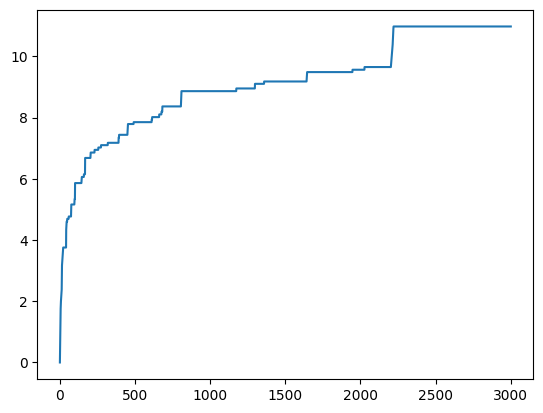

In [24]:
T = 3000 
alg.reset()
env.reset()
reg = [0]
cum_reg = 0
for _ in range(T): 
    X = env.observe_context() 
    a_t = alg.take_action(X, alpha=0.03) 
    r = env.get_reward(arm=a_t) 
    cum_reg += env.get_regret(arm=a_t) 
    reg.append(cum_reg)
    alg.update(action=a_t, reward=r, context=X)
    
import matplotlib.pyplot as plt 

plt.plot(range(T+1), reg)
plt.show()

In [11]:
alg.counts

array([ 180.,   85.,  186.,   54.,  160.,   48., 1292.,   51.,   53.,
         62.,   41.,  101.,   76.,   53.,  124.,   39.,  101.,   93.,
        168.,   33.])

In [12]:
alg.reward_his

array([ 0.2007277 ,  0.08812873,  0.01515103, ...,  0.67888475,
        0.67682495, -0.11727786])

In [13]:
alg.V_inv

array([[ 0.06357341, -0.07615933,  0.03328862, -0.02712887,  0.0146986 ,
         0.02554679,  0.03153564,  0.02359474,  0.06216751,  0.00057048,
        -0.01028534, -0.04878473,  0.0271761 , -0.04680092,  0.014181  ,
        -0.03212068,  0.02064045, -0.02536754, -0.02332012,  0.08648513],
       [-0.07615933,  0.27043188, -0.01536363, -0.00434866, -0.03295477,
        -0.00792034, -0.12188838, -0.03238855, -0.11810964, -0.0254744 ,
         0.06561854,  0.07201103, -0.05237838,  0.06787735, -0.00767479,
         0.10753223, -0.09931282,  0.08931436,  0.06076063, -0.10688454],
       [ 0.03328862, -0.01536363,  0.10289355, -0.05427169,  0.04620073,
         0.03618732,  0.03083187, -0.00540345,  0.04750056, -0.04504555,
        -0.02888108, -0.12305794, -0.00650945,  0.0434288 ,  0.02709239,
        -0.0379292 , -0.06189556, -0.02834576, -0.00168294,  0.1205071 ],
       [-0.02712887, -0.00434866, -0.05427169,  0.09176056, -0.01986613,
         0.0010683 , -0.01295446,  0.0412114 , -

In [14]:
alg.theta

array([ 0.17290298, -0.25794341,  0.03376609,  0.0477932 ,  0.3099398 ,
       -0.0249834 , -0.39265415, -0.22751206, -0.13153583,  0.0096046 ,
       -0.26024114,  0.11614886,  0.03679716,  0.05180986, -0.30537318,
       -0.06628199, -0.21504192,  0.20376729, -0.41944962, -0.09761548])

In [15]:
env.theta

array([ 0.22176758, -0.35718089,  0.07978866,  0.01131395,  0.36487035,
        0.01390527, -0.37519973, -0.220173  , -0.00289136,  0.00320227,
       -0.27289229,  0.1105207 ,  0.07468146,  0.02500838, -0.33008612,
       -0.09748137, -0.23827498,  0.11782622, -0.45950255,  0.01226186])

In [16]:
env.optimal_arm

6